In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


In [3]:
df = pd.read_csv("SDSS_DR18.csv")

In [4]:
df.head()

,objid,specobjid,ra,dec,u,g,r,i,z,run,...,psfMag_g,psfMag_i,psfMag_z,expAB_u,expAB_g,expAB_r,expAB_i,expAB_z,redshift,class
0,1.240000e+18,3.240000e+17,184.950869,0.733068,18.87062,17.59612,17.11245,16.83899,16.70908,756,...,19.96352,19.25145,19.05230,0.479021,0.518483,0.520474,0.508502,0.488969,0.041691,GALAXY
1,1.240000e+18,3.250000e+17,185.729201,0.679704,19.59560,19.92153,20.34448,20.66213,20.59599,756,...,19.92417,20.65535,20.57387,0.573926,0.531728,0.403072,0.999874,0.189495,-0.000814,STAR
2,1.240000e+18,3.240000e+17,185.687690,0.823480,19.26421,17.87891,17.09593,16.65159,16.35329,756,...,19.33645,18.16669,17.78844,0.701666,0.743386,0.770897,0.778642,0.736771,0.113069,GALAXY
3,1.240000e+18,2.880000e+18,185.677904,0.768362,19.49739,17.96166,17.41269,17.20545,17.11567,756,...,17.96176,17.21564,17.12367,0.999818,0.787760,0.745611,0.399718,0.986137,0.000087,STAR
4,1.240000e+18,2.880000e+18,185.814763,0.776940,18.31519,16.83033,16.26352,16.06320,15.97527,756,...,16.85104,16.08275,15.98694,0.999795,0.834450,0.723526,0.712259,0.527055,0.000018,STAR


In [5]:
df_need = df[['u', 'g', 'r', 'i', 'z', 'redshift','class']]

In [6]:
df_need.describe()

,u,g,r,i,z,redshift
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,18.641137,17.407088,16.878550,16.517137,16.154837,0.168441
std,0.829035,0.974683,1.118858,31.694636,54.871034,0.434285
min,11.726470,11.696170,11.277090,-9999.000000,-9999.000000,-0.004268
25%,18.214315,16.853340,16.194763,15.861995,15.620268,0.000065
50%,18.878005,17.520310,16.896065,16.594740,16.419040,0.048772
75%,19.275750,18.052460,17.565593,17.310102,17.193873,0.096680
max,19.599990,19.977270,31.698160,30.980870,28.668700,6.990327


In [8]:
df_need.isna().sum()

u           0
g           0
r           0
i           0
z           0
redshift    0
class       0
dtype: int64

In [15]:
df_need.duplicated().sum()

np.int64(0)

In [7]:
df_need['class'].value_counts()

class
GALAXY    52343
STAR      37232
QSO       10425
Name: count, dtype: int64

In [16]:
df_need['class_encoded'] = df_need['class'].map({'GALAXY': 0, 'QSO': 1, 'STAR': 2})
labels = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}

In [17]:
df_need.head()

,u,g,r,i,z,redshift,class,class_encoded
0,18.87062,17.59612,17.11245,16.83899,16.70908,0.041691,GALAXY,0
1,19.59560,19.92153,20.34448,20.66213,20.59599,-0.000814,STAR,2
2,19.26421,17.87891,17.09593,16.65159,16.35329,0.113069,GALAXY,0
3,19.49739,17.96166,17.41269,17.20545,17.11567,0.000087,STAR,2
4,18.31519,16.83033,16.26352,16.06320,15.97527,0.000018,STAR,2


In [30]:
df_need['u_g'] = df_need['u'] - df_need['g']
df_need['g_r'] = df_need['g'] - df_need['r']
df_need['r_i'] = df_need['r'] - df_need['i']
df_need['i_z'] = df_need['i'] - df_need['z']

In [34]:
x = df_need[['u_g', 'g_r', 'r_i', 'i_z', 'redshift']]
y = df_need['class_encoded']

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [36]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [39]:
model = XGBClassifier()
grid_parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}
grid_search = GridSearchCV(estimator=model, param_grid=grid_parameters, scoring='accuracy', cv=3, n_jobs=-1)
grid_search.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

In [40]:
grid_search.best_params_

{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}

In [41]:
grid_search.best_score_

np.float64(0.9922374948412598)

In [44]:
y_pred = grid_search.predict(x_test_scaled)
y_train_pred = grid_search.predict(x_train_scaled)

In [ ]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(grid_search.best_estimator_, x_train_scaled, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", score)
print("Mean Cross-Validation Score:", score.mean())

Cross-Validation Scores: [0.993625  0.99225   0.9925625 0.991875  0.9919375]
Mean Cross-Validation Score: 0.99245


In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("y_train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=labels.values()))

Accuracy: 0.9921
y_train Accuracy: 0.9981125
Classification Report:
               precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99     10373
         QSO       0.99      0.96      0.98      2115
        STAR       0.99      1.00      1.00      7512

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



<Axes: >

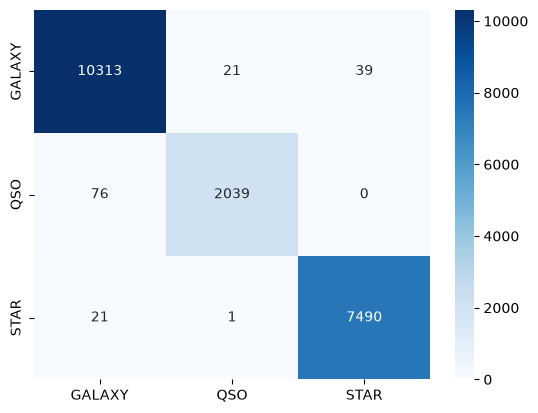

In [49]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels.values(), yticklabels=labels.values())

In [51]:
y_test.value_counts()

class_encoded
0    10373
2     7512
1     2115
Name: count, dtype: int64

In [55]:
df1 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df1['Actual'].value_counts()


Actual
0    10373
2     7512
1     2115
Name: count, dtype: int64

In [56]:
df1['Predicted'].value_counts()

Predicted
0    10410
2     7529
1     2061
Name: count, dtype: int64